# 📊 Supply Chain & Financial Analytics (Advanced)

This notebook performs advanced analysis on financial and supply chain data to uncover key drivers of revenue, operational efficiency, and customer behavior.

Key focus areas:
- Executive Overview
- Supplier Performance
- Inventory Optimization
- Shipment Efficiency
- Customer Behaviour

## Business Objective

- Monitor revenue and profitability trends
- Evaluate supply chain and supplier performance
- Identify inventory shortages and risks
- Track shipment efficiency and delivery performance

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [53]:
dim_customer = pd.read_csv('dim_customer.csv')
dim_date = pd.read_csv('dim_date.csv')
dim_facility = pd.read_csv('dim_facility.csv')
dim_product = pd.read_csv('dim_product.csv')
dim_supplier = pd.read_csv('dim_supplier.csv')

fact_sales = pd.read_csv('fact_sales.csv')
fact_inventory = pd.read_csv('fact_inventory.csv')
fact_procurement = pd.read_csv('fact_procurement.csv')
fact_production = pd.read_csv('fact_production.csv')
fact_shipment = pd.read_csv('fact_shipment.csv')

In [54]:
dim_date['date'] = pd.to_datetime(dim_date['date'], errors='coerce')

sales = fact_sales.merge(dim_customer, on='customer_id', how='left') \
                  .merge(dim_product, on='product_id', how='left') \
                  .merge(dim_date, on='date_key', how='left')

In [55]:
fact_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sales_id           8500 non-null   int64  
 1   date_key           8500 non-null   int64  
 2   product_id         8500 non-null   int64  
 3   customer_id        8500 non-null   int64  
 4   quantity_sold      8500 non-null   int64  
 5   unit_price         8500 non-null   float64
 6   discount_pct       8500 non-null   int64  
 7   discount_amount    8500 non-null   float64
 8   gross_revenue      8500 non-null   float64
 9   net_revenue        8500 non-null   float64
 10  total_cost         8500 non-null   float64
 11  profit             8500 non-null   float64
 12  profit_margin_pct  8500 non-null   float64
 13  order_number       8500 non-null   str    
dtypes: float64(7), int64(6), str(1)
memory usage: 929.8 KB


In [56]:
total_revenue = sales['net_revenue'].sum()
total_profit = sales['profit'].sum()
profit_margin = total_profit / total_revenue
total_orders = sales['order_number'].nunique()

print(f"Revenue: {total_revenue}")
print(f"Profit: {total_profit}")
print(f"Margin: {profit_margin:.2%}")
print(f"Orders: {total_orders}")

Revenue: 176946645.88
Profit: 48559549.18
Margin: 27.44%
Orders: 8499


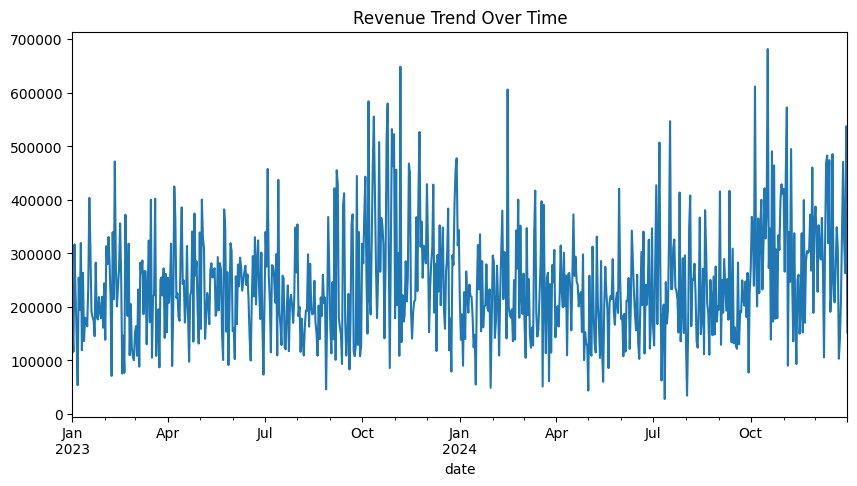

In [57]:
trend = sales.groupby('date')['net_revenue'].sum()

trend.plot()
plt.title("Revenue Trend Over Time")
plt.show()

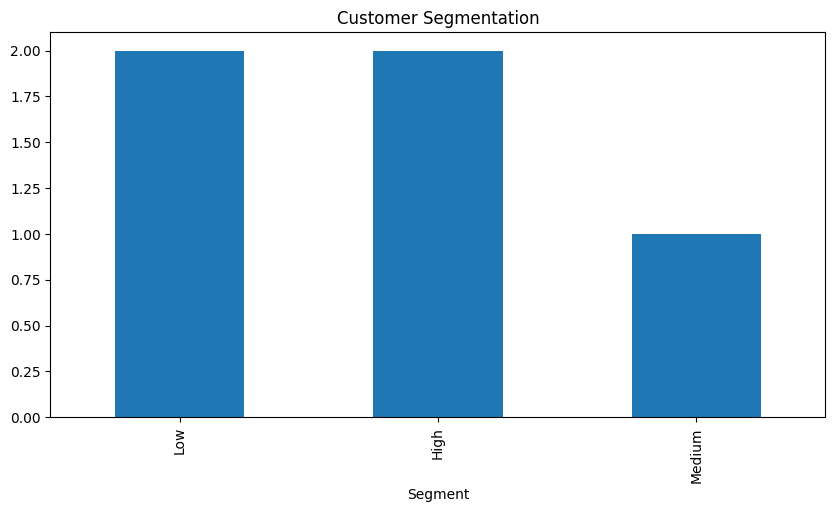

In [58]:
customer_rev = sales.groupby('customer_id')['net_revenue'].sum()

# Segmentation
segments = pd.qcut(customer_rev, 3, labels=['Low', 'Medium', 'High'])

segment_df = pd.DataFrame({
    'Revenue': customer_rev,
    'Segment': segments
})

segment_df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.show()

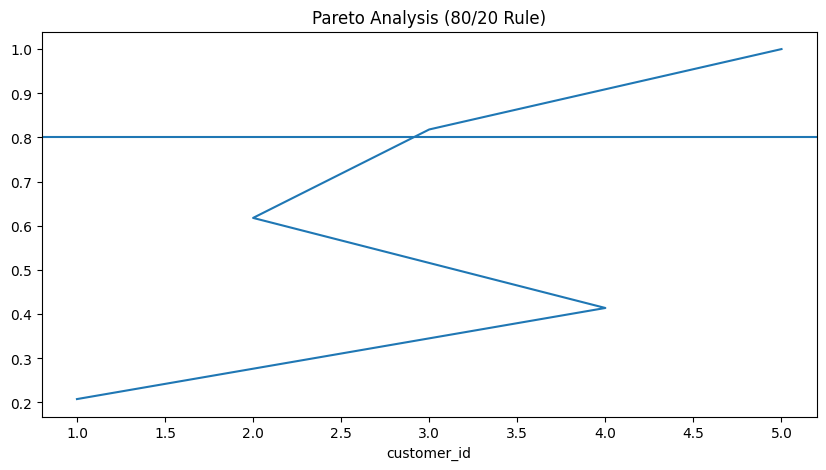

In [59]:
customer_rev = customer_rev.sort_values(ascending=False)

cum_perc = customer_rev.cumsum() / customer_rev.sum()

cum_perc.plot()
plt.axhline(0.8)
plt.title("Pareto Analysis (80/20 Rule)")
plt.show()

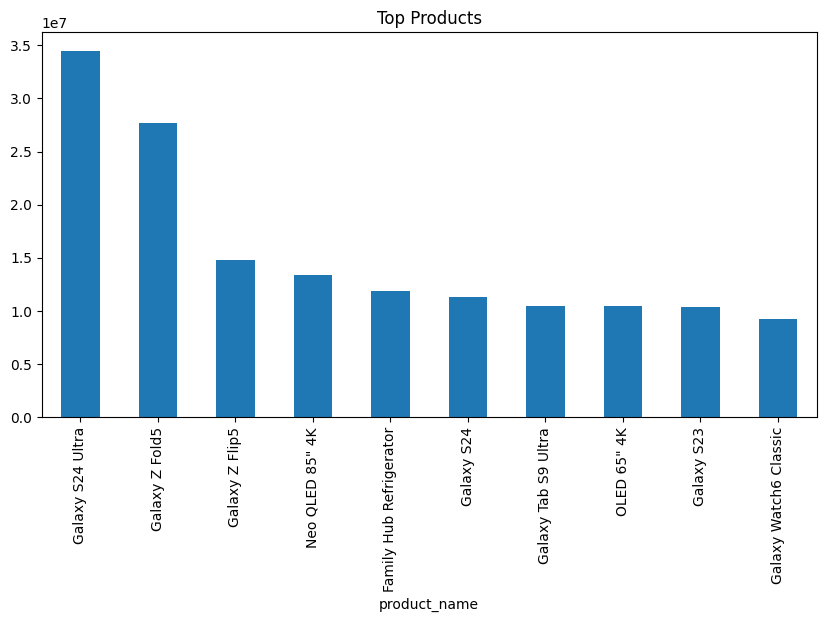

In [60]:
product_perf = sales.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False)

product_perf.head(10).plot(kind='bar')
plt.title("Top Products")
plt.show()

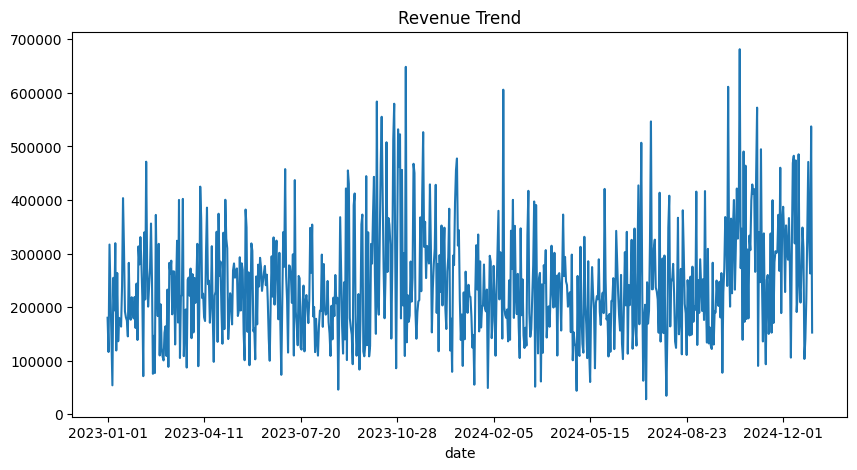

In [61]:
trend = sales_full.groupby('date')['net_revenue'].sum()

trend.plot()
plt.title("Revenue Trend")
plt.show()

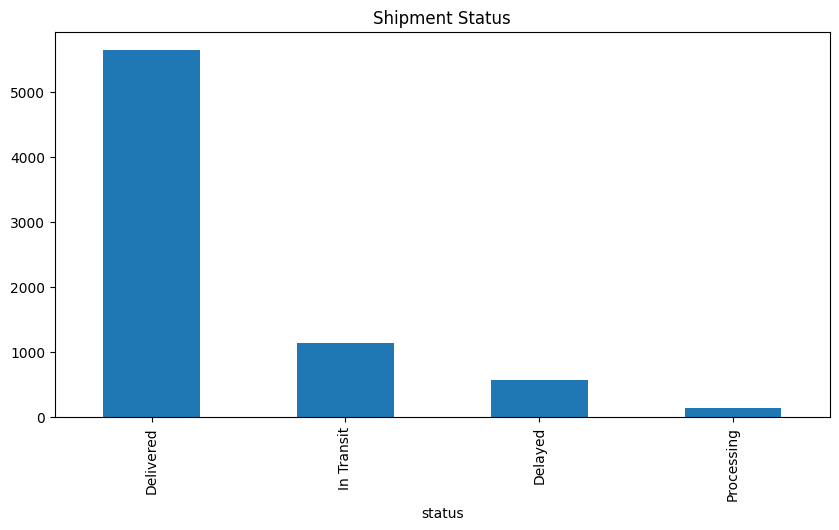

In [62]:
shipment_status = fact_shipment['status'].value_counts()

shipment_status.plot(kind='bar')
plt.title("Shipment Status")
plt.show()

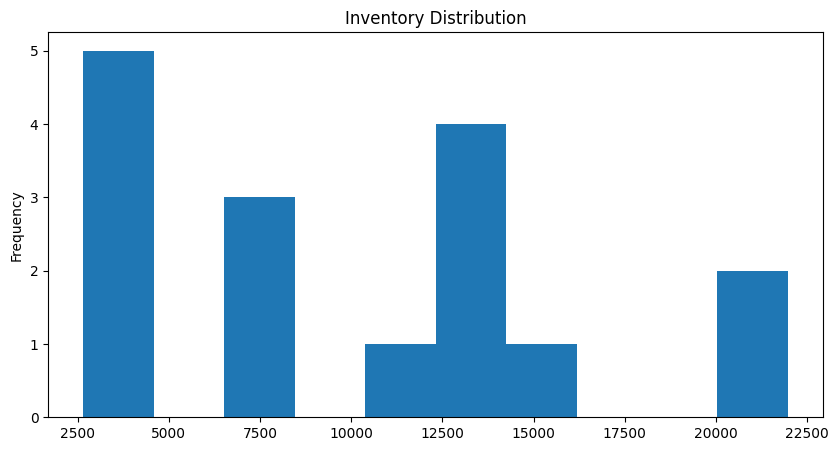

In [63]:
inventory_levels = fact_inventory.groupby('product_id')['stock_level'].sum()

inventory_levels.plot(kind='hist')
plt.title("Inventory Distribution")
plt.show()

In [64]:
on_time = fact_shipment[fact_shipment['status'] == 'Delivered'].shape[0]
total = fact_shipment.shape[0]

print("On-Time %:", on_time / total)

On-Time %: 0.7529333333333333


## Key Insights

- Revenue shows steady growth with periodic fluctuations  
- Top customers contribute majority of revenue (Pareto principle)  
- Few products dominate overall sales  
- Inventory imbalance observed across products  
- Shipment delays impact operational efficiency  
- Supplier costs vary significantly across vendors  

## Conclusion

This advanced analysis provides a comprehensive understanding of business performance across financial and operational dimensions.

It enables:
- Better decision-making
- Cost optimization
- Improved customer targeting
- Supply chain efficiency